# Pizza Sales Performance Analysis

This notebook analyzes one year of pizza-shop transactions to answer four business questions: How much did the shop sell? Which products performed best? When was demand highest? And where might the menu deserve further attention?

The workflow covers data quality, time-based feature engineering, KPI calculation, product and mix performance, and demand patterns.

## 1. Load the data

Load the `pizza_sales` worksheet and preview its transaction-level structure.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "pizza_sales.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="pizza_sales")
df.head()

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## 2. Validate data quality

Check the dataset shape, schema, missing values, and exact duplicate rows before calculating business metrics.

In [2]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Rows and columns: (48620, 12)

Column names:
['order_details_id', 'order_id', 'pizza_id', 'quantity', 'order_date', 'order_time', 'unit_price', 'total_price', 'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name']

Missing values:
order_details_id     0
order_id             0
pizza_id             0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

Duplicate rows: 0


## 3. Engineer time features

Combine the date and time fields, then derive calendar dimensions used for demand analysis.

In [3]:
df["order_datetime"] = pd.to_datetime(
    df["order_date"].astype(str) + " " + df["order_time"].astype(str)
)

df["day_of_week"] = df["order_datetime"].dt.day_name()
df["hour"] = df["order_datetime"].dt.hour
df["month"] = df["order_datetime"].dt.month_name()

df[["order_datetime", "day_of_week", "hour", "month"]].head()

,order_datetime,day_of_week,hour,month
0,2015-01-01 11:38:36,Thursday,11,January
1,2015-01-01 11:57:40,Thursday,11,January
2,2015-01-01 11:57:40,Thursday,11,January
3,2015-01-01 11:57:40,Thursday,11,January
4,2015-01-01 11:57:40,Thursday,11,January


## 4. Measure headline and product performance

Calculate the core KPIs, then rank pizzas by revenue, units sold, and order reach.

In [4]:
summary = {
    "Total revenue": df["total_price"].sum(),
    "Total orders": df["order_id"].nunique(),
    "Pizzas sold": df["quantity"].sum(),
    "Average order value": df.groupby("order_id")["total_price"].sum().mean()
}

for label, value in summary.items():
    print(f"{label}: {value:,.2f}")

pizza_performance = (
    df.groupby("pizza_name")
      .agg(
          revenue=("total_price", "sum"),
          pizzas_sold=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

print("\nTop 10 pizzas by revenue:")
display(pizza_performance.head(10))

print("\nBottom 10 pizzas by revenue:")
display(pizza_performance.tail(10))

Total revenue: 817,860.05
Total orders: 21,350.00
Pizzas sold: 49,574.00
Average order value: 38.31

Top 10 pizzas by revenue:


,revenue,pizzas_sold,orders
pizza_name,,,
The Thai Chicken Pizza,43434.25,2371,2225
The Barbecue Chicken Pizza,42768.00,2432,2273
The California Chicken Pizza,41409.50,2370,2197
The Classic Deluxe Pizza,38180.50,2453,2329
The Spicy Italian Pizza,34831.25,1924,1822
The Southwest Chicken Pizza,34705.75,1917,1825
The Italian Supreme Pizza,33476.75,1884,1791
The Hawaiian Pizza,32273.25,2422,2280
The Four Cheese Pizza,32265.70,1902,1809



Bottom 10 pizzas by revenue:


,revenue,pizzas_sold,orders
pizza_name,,,
The Chicken Alfredo Pizza,16900.25,987,967
The Chicken Pesto Pizza,16701.75,973,938
The Soppressata Pizza,16425.75,961,941
The Italian Vegetables Pizza,16019.25,981,952
The Calabrese Pizza,15934.25,937,918
The Spinach Pesto Pizza,15596.00,970,945
The Mediterranean Pizza,15360.50,934,912
The Spinach Supreme Pizza,15277.75,950,918
The Green Garden Pizza,13955.75,997,976


### Top products by revenue

The leading products reveal which menu items contribute most to overall sales.

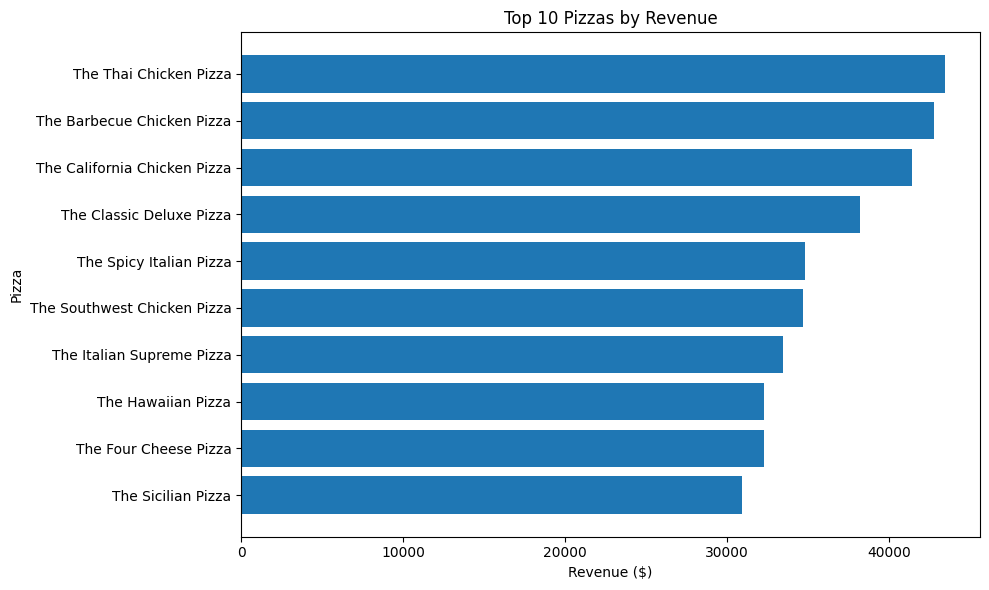

In [5]:
top_10 = pizza_performance.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_10.index, top_10["revenue"])
plt.title("Top 10 Pizzas by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Pizza")
plt.tight_layout()
plt.show()

## 5. Analyze demand patterns

Aggregate unique orders by weekday and hour to identify the shop's busiest operating windows.

In [6]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_performance = (
    df.groupby("day_of_week")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("total_price", "sum"),
          pizzas_sold=("quantity", "sum")
      )
      .reindex(day_order)
)

hourly_performance = (
    df.groupby("hour")
      .agg(
          orders=("order_id", "nunique"),
          revenue=("total_price", "sum"),
          pizzas_sold=("quantity", "sum")
      )
)

print("Performance by weekday:")
display(daily_performance)

print("\nPerformance by hour:")
display(hourly_performance)

Performance by weekday:


,orders,revenue,pizzas_sold
day_of_week,,,
Monday,2794,107329.55,6485
Tuesday,2973,114133.80,6895
Wednesday,3024,114408.40,6946
Thursday,3239,123528.50,7478
Friday,3538,136073.90,8242
Saturday,3158,123182.40,7493
Sunday,2624,99203.50,6035



Performance by hour:


,orders,revenue,pizzas_sold
hour,,,
9,1,83.00,4
10,8,303.65,18
11,1231,44935.80,2728
12,2520,111877.90,6776
13,2455,106065.70,6413
14,1472,59201.40,3613
15,1468,52992.30,3216
16,1920,70055.40,4239
17,2336,86237.45,5211


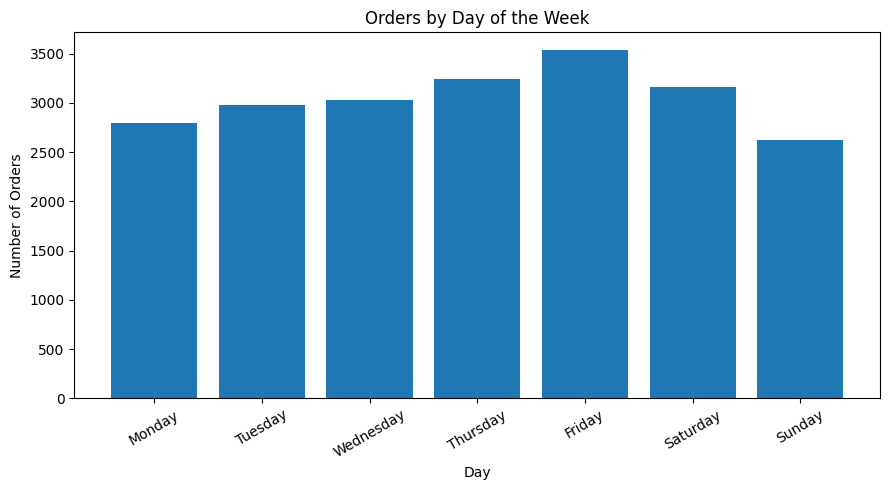

In [7]:
# Orders by weekday
plt.figure(figsize=(9, 5))
plt.bar(daily_performance.index, daily_performance["orders"])
plt.title("Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

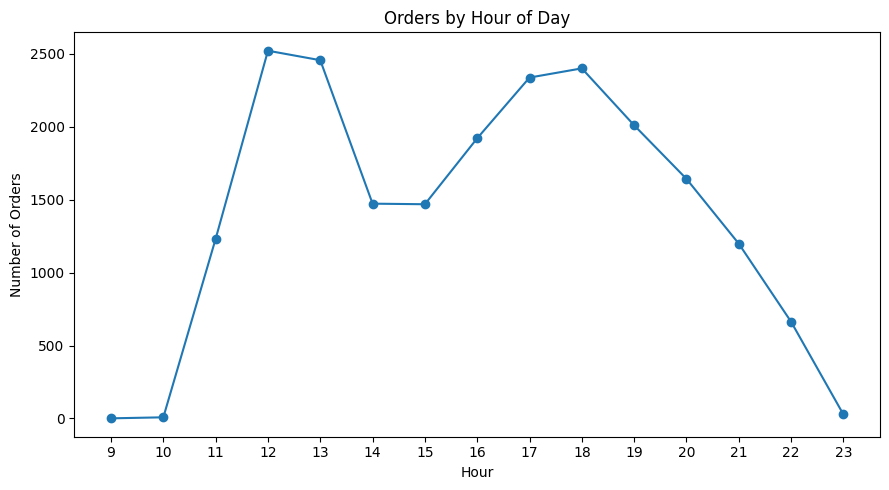

In [8]:
# Orders by hour
plt.figure(figsize=(9, 5))
plt.plot(hourly_performance.index, hourly_performance["orders"], marker="o")
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(hourly_performance.index)
plt.tight_layout()
plt.show()

## 6. Compare category and size mix

Review how menu categories and pizza sizes contribute to revenue and volume, then identify low-volume products.

In [9]:
category_performance = (
    df.groupby("pizza_category")
      .agg(
          revenue=("total_price", "sum"),
          pizzas_sold=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

size_performance = (
    df.groupby("pizza_size")
      .agg(
          revenue=("total_price", "sum"),
          pizzas_sold=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

lowest_volume_pizzas = pizza_performance.sort_values("pizzas_sold").head(10)

print("Performance by pizza category:")
display(category_performance)

print("\nPerformance by pizza size:")
display(size_performance)

print("\nLowest-selling pizzas:")
display(lowest_volume_pizzas)

Performance by pizza category:


,revenue,pizzas_sold,orders
pizza_category,,,
Classic,220053.10,14888,10859
Supreme,208197.00,11987,9085
Chicken,195919.50,11050,8536
Veggie,193690.45,11649,8941



Performance by pizza size:


,revenue,pizzas_sold,orders
pizza_size,,,
L,375318.70,18956,12736
M,249382.25,15635,11159
S,178076.50,14403,10490
XL,14076.00,552,544
XXL,1006.60,28,28



Lowest-selling pizzas:


,revenue,pizzas_sold,orders
pizza_name,,,
The Brie Carre Pizza,11588.50,490,480
The Mediterranean Pizza,15360.50,934,912
The Calabrese Pizza,15934.25,937,918
The Spinach Supreme Pizza,15277.75,950,918
The Soppressata Pizza,16425.75,961,941
The Spinach Pesto Pizza,15596.00,970,945
The Chicken Pesto Pizza,16701.75,973,938
The Italian Vegetables Pizza,16019.25,981,952
The Chicken Alfredo Pizza,16900.25,987,967


In [10]:
print("Top pizza by revenue:")
display(pizza_performance.head(1))

print("Lowest pizza by revenue:")
display(pizza_performance.tail(1))

print("Busiest weekday:")
display(daily_performance.sort_values("orders", ascending=False).head(1))

print("Busiest hour:")
display(hourly_performance.sort_values("orders", ascending=False).head(1))

print("Top category:")
display(category_performance.head(1))

print("Top size:")
display(size_performance.head(1))

Top pizza by revenue:


,revenue,pizzas_sold,orders
pizza_name,,,
The Thai Chicken Pizza,43434.25,2371,2225


Lowest pizza by revenue:


,revenue,pizzas_sold,orders
pizza_name,,,
The Brie Carre Pizza,11588.5,490,480


Busiest weekday:


...

,orders,revenue,pizzas_sold
hour,,,
12,2520,111877.9,6776


Top category:


,revenue,pizzas_sold,orders
pizza_category,,,
Classic,220053.1,14888,10859


Top size:


,revenue,pizzas_sold,orders
pizza_size,,,
L,375318.7,18956,12736


## Conclusions

The business generated **$817,860.05** from **21,350 orders** and sold **49,574 pizzas**. The Thai Chicken Pizza led revenue, Friday was the busiest weekday, and demand peaked at noon with a second strong window during dinner. Classic pizzas and large sizes produced the most revenue. At the other end of the menu, the Brie Carre Pizza recorded the lowest unit volume and is a reasonable candidate for promotion, repositioning, or menu review.